# Course 2: Python Project 03_Exploratory Data Analysis on YouTube data.

 In a fairly recent move by Youtube, it announced the decision to hide the
number of dislikes from users around November 2021. However, the official YouTube Data API allowed you to
get information about dislikes until December 13, 2021. Doing an EDA-exercise can help to draw some unseen
insights from this dataset.

### 1. Import required libraries and read the provided dataset (youtube_dislike_dataset.csv) and retrieve top5 and bottom 5 records.

In [1]:
# Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# Reading the dataset
dataframe=pd.read_csv("youtube_dislike_dataset.csv")

In [3]:
#retrieving top 5 records
dataframe.head()

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments
0,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi..."
1,--14w5SOEUs,Migos - Avalanche (Official Video),UCGIelM2Dj3zza3xyV3pL3WQ,MigosVEVO,2021-06-10 16:00:00,15352638,359277,7479,18729,Migos Avalanche Quality Control Music/Motown R...,"Watch the the official video for Migos - ""Aval...",Migos just makes me want to live my live to th...
2,--40TEbZ9Is,Supporting Actress in a Comedy: 73rd Emmys,UClBKH8yZRcM4AsRjDVEdjMg,Television Academy,2021-09-20 01:03:32,925281,11212,401,831,,Hannah Waddingham wins the Emmy for Supporting...,Hannah's energy bursts through any screen. Wel...
3,--4tfbSyYDE,JO1'YOUNG (JO1 ver.)' PERFORMANCE VIDEO,UCsmXiDP8S40uBeJYxvyulmA,JO1,2021-03-03 10:00:17,2641597,39131,441,3745,PRODUCE101JAPAN JO1 TheSTAR STA...,JO1'YOUNG (JO1 ver.)' PERFORMANCE VIDEO\n\n---...,youngVer>< REN is really PERFECT. It's not ju...
4,--DKkzWVh-E,Why Retaining Walls Collapse,UCMOqf8ab-42UUQIdVoKwjlQ,Practical Engineering,2021-12-07 13:00:00,715724,32887,367,1067,retaining wall New Jersey highway Direct Conne...,One of the most important (and innocuous) part...,Keep up with all my projects here: https://pr...


In [4]:
#retrieving bottom 5 records
dataframe.tail()

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments
37417,zzd4ydafGR0,Lil Tjay - Calling My Phone (feat. 6LACK) [Off...,UCEB4a5o_6KfjxHwNMnmj54Q,Lil Tjay,2021-02-12 05:03:49,120408275,2180780,35871,81360,Lil Tjay Steady Calling My Phone Calling My Ph...,"Official video for ""Calling My Phone"" by Lil T...",'DESTINED 2 WIN' OUT NOW !! https://liltjay.ln...
37418,zziBybeSAtw,PELICANS at LAKERS | FULL GAME HIGHLIGHTS | Ja...,UCWJ2lWNubArHWmf3FIHbfcQ,NBA,2021-01-16 05:39:05,2841917,20759,1049,2624,NBA G League Basketball game-0022000187 Lakers...,PELICANS at LAKERS | FULL GAME HIGHLIGHTS | Ja...,Montrezl Harrell is going crazy with the rebou...
37419,zzk09ESX7e0,[MV] (MAMAMOO) - Where Are We Now,UCuhAUMLzJxlP1W7mEk0_6lA,MAMAMOO,2021-06-02 09:00:10,13346678,720854,4426,90616,MAMAMOO WAW WAW MAMAMOO WAW Where Are We Now...,[MV] (MAMAMOO) - Where Are We Now\n\nInstagra...,I honestly do not know why this song hit so ha...
37420,zzmQEb0Em5I,FELLIPE ESCUDERO- Master Podcast #12,UC8NjnNWMsRqq11NYvHAQb1g,Master Podcast,2020-10-20 20:59:30,252057,19198,1234,1471,master masterpodcast lord lord vinheteiro z z ...,DOCTOR HAIR\nhttps://www.thedoctorhair.com/?fb...,Foi um prazer passar esta tarde com vocs debat...
37421,zzxPZwaA-8w,Gareth Bale brace secures dramatic comeback on...,UCEg25rdRZXg32iwai6N6l0w,Tottenham Hotspur,2021-05-23 21:00:31,2252090,34063,868,2004,Spurs Tottenham Hotspur Tottenham Leicester ...,Two minute highlights from Tottenham Hotspur's...,Thank you Kane for everything you have given t...


### 2. Check the info of the dataframe and write your inferences on data types and shape of the dataset.

In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37422 entries, 0 to 37421
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       37422 non-null  object
 1   title          37422 non-null  object
 2   channel_id     37422 non-null  object
 3   channel_title  37422 non-null  object
 4   published_at   37422 non-null  object
 5   view_count     37422 non-null  int64 
 6   likes          37422 non-null  int64 
 7   dislikes       37422 non-null  int64 
 8   comment_count  37422 non-null  int64 
 9   tags           37422 non-null  object
 10  description    37422 non-null  object
 11  comments       37264 non-null  object
dtypes: int64(4), object(8)
memory usage: 3.4+ MB


The dataframe contains 37422 entries i.e. 37422 rows and total 12 columns. In that 12 columns 4 columns have integer type data and 8 columns have object type data and there is some missing values are present in comments column.

### 3. Check for the Percentage of the missing values and drop or impute them.

In [6]:
percent_missing = dataframe.isnull().sum() * 100 / len(dataframe)
percent_missing

video_id         0.000000
title            0.000000
channel_id       0.000000
channel_title    0.000000
published_at     0.000000
view_count       0.000000
likes            0.000000
dislikes         0.000000
comment_count    0.000000
tags             0.000000
description      0.000000
comments         0.422212
dtype: float64

except "comments" column there is no missing values present in any others columns.
and the percentage of missing values for "comments" column is about 0.42%

In [7]:
#dropping the missing values from the dataframe
dataframe_dropped_missing = dataframe.dropna()

In [8]:
dataframe_dropped_missing.isnull().sum()

video_id         0
title            0
channel_id       0
channel_title    0
published_at     0
view_count       0
likes            0
dislikes         0
comment_count    0
tags             0
description      0
comments         0
dtype: int64

In [9]:
dataframe_dropped_missing

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments
0,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi..."
1,--14w5SOEUs,Migos - Avalanche (Official Video),UCGIelM2Dj3zza3xyV3pL3WQ,MigosVEVO,2021-06-10 16:00:00,15352638,359277,7479,18729,Migos Avalanche Quality Control Music/Motown R...,"Watch the the official video for Migos - ""Aval...",Migos just makes me want to live my live to th...
2,--40TEbZ9Is,Supporting Actress in a Comedy: 73rd Emmys,UClBKH8yZRcM4AsRjDVEdjMg,Television Academy,2021-09-20 01:03:32,925281,11212,401,831,,Hannah Waddingham wins the Emmy for Supporting...,Hannah's energy bursts through any screen. Wel...
3,--4tfbSyYDE,JO1'YOUNG (JO1 ver.)' PERFORMANCE VIDEO,UCsmXiDP8S40uBeJYxvyulmA,JO1,2021-03-03 10:00:17,2641597,39131,441,3745,PRODUCE101JAPAN JO1 TheSTAR STA...,JO1'YOUNG (JO1 ver.)' PERFORMANCE VIDEO\n\n---...,youngVer>< REN is really PERFECT. It's not ju...
4,--DKkzWVh-E,Why Retaining Walls Collapse,UCMOqf8ab-42UUQIdVoKwjlQ,Practical Engineering,2021-12-07 13:00:00,715724,32887,367,1067,retaining wall New Jersey highway Direct Conne...,One of the most important (and innocuous) part...,Keep up with all my projects here: https://pr...
...,...,...,...,...,...,...,...,...,...,...,...,...
37417,zzd4ydafGR0,Lil Tjay - Calling My Phone (feat. 6LACK) [Off...,UCEB4a5o_6KfjxHwNMnmj54Q,Lil Tjay,2021-02-12 05:03:49,120408275,2180780,35871,81360,Lil Tjay Steady Calling My Phone Calling My Ph...,"Official video for ""Calling My Phone"" by Lil T...",'DESTINED 2 WIN' OUT NOW !! https://liltjay.ln...
37418,zziBybeSAtw,PELICANS at LAKERS | FULL GAME HIGHLIGHTS | Ja...,UCWJ2lWNubArHWmf3FIHbfcQ,NBA,2021-01-16 05:39:05,2841917,20759,1049,2624,NBA G League Basketball game-0022000187 Lakers...,PELICANS at LAKERS | FULL GAME HIGHLIGHTS | Ja...,Montrezl Harrell is going crazy with the rebou...
37419,zzk09ESX7e0,[MV] (MAMAMOO) - Where Are We Now,UCuhAUMLzJxlP1W7mEk0_6lA,MAMAMOO,2021-06-02 09:00:10,13346678,720854,4426,90616,MAMAMOO WAW WAW MAMAMOO WAW Where Are We Now...,[MV] (MAMAMOO) - Where Are We Now\n\nInstagra...,I honestly do not know why this song hit so ha...
37420,zzmQEb0Em5I,FELLIPE ESCUDERO- Master Podcast #12,UC8NjnNWMsRqq11NYvHAQb1g,Master Podcast,2020-10-20 20:59:30,252057,19198,1234,1471,master masterpodcast lord lord vinheteiro z z ...,DOCTOR HAIR\nhttps://www.thedoctorhair.com/?fb...,Foi um prazer passar esta tarde com vocs debat...


So after dropping missing values, now we have total 37264 rows and 12 columns in the dataframe.

### 4. Check the statistical summary of both numerical and categorical columns and write your inferences.

In [10]:
youtube_dataframe=dataframe_dropped_missing.copy()     #taking the copy of dataframe

In [11]:
#statistical summary for numerical column
youtube_dataframe.describe() 

,view_count,likes,dislikes,comment_count
count,3.726400e+04,3.726400e+04,3.726400e+04,3.726400e+04
mean,5.710821e+06,1.672867e+05,4.996434e+03,9.966953e+03
std,2.431304e+07,5.384931e+05,3.075194e+04,1.173465e+05
min,2.036800e+04,2.200000e+01,3.000000e+00,1.000000e+00
25%,5.141305e+05,1.331725e+04,2.827500e+02,9.140000e+02
50%,1.321860e+06,4.255600e+04,7.980000e+02,2.347000e+03
75%,3.674527e+06,1.309665e+05,2.466250e+03,6.212000e+03
max,1.322797e+09,3.183768e+07,2.397733e+06,1.607103e+07


1. The total count for views, likes, dislikes and the comments in the dataset is 37264.
2. An everage view count of the video in the dataset is 5710821, the everage likes are 167286, the everage dislikes are 4996 and the everage comment count is 9966.
3. There are lots of variations in views, likes,dislikes,and in comments count.
4. The minimum view count of an video is 20368 and the maximum view count of an video is 1322797000, the minimum likes for video in dataset is 22 and the maximum likes for video in dataset is 31827680,the minimum dislike for video is 3 and the maximum dislike for video is 2397733,the minimum comments for video in dataset is 1 and the maximum comments for video in dataset is 16071030.
5. In that data set 25% of view count are below 514130, 25% of likes are below 13317, 25% of dislikes are below 282 and 25% of comments are below 914.
6. In that data set 50% of view count are below 1321860, 50% of likes are below 42556, 50% of dislikes are below 798 and 50% of comments are below 2347.
7. In that data set 75% of view count are below 3674527, 75% of likes are below 130966, 75% of dislikes are below 2466 and 75% of comments are below 6212.

In [12]:
#statistical summary for both numerical and categorical columns
youtube_dataframe.describe(include="object")         

,video_id,title,channel_id,channel_title,published_at,tags,description,comments
count,37264,37264,37264,37264,37264,37264,37264,37264
unique,37264,36958,10891,10813,36617,28705,35479,37264
top,--0bCF-iK2E,www,UCNAf1k0yIjyGu3k9BwAg3lg,Sky Sports Football,2020-10-16 04:00:10,,,"Respect to Dortmund fans,must be sad losing hi..."
freq,1,21,533,533,6,3808,587,1


1. The total count for video_id, video title, channel_id, channel_title, video published date, tags, description of video and comments is 37264.
2. There are 37264 unique video id's are there in the dataset, and there are 36958 unique video titles are there, and 10891 unique channel id's are there, and 10813 unique channel title are there, and there are 36617 diffrent dates are there, and 28705 unique tags are there, there are 35479 diffrent discription are there for videos in the dataset, and there are 37264 different comments are there for the videos in the dataset.
3. The frequency for video_id is 1, for title is 21, for channel_id is 533, for channel title 533 for date 6, for tags 3808, for discription 587 for comments 1.

### 5. Convert datatype of column published_at from object to pandas datetime.

In [13]:
youtube_dataframe['published_at'] = pd.to_datetime(youtube_dataframe['published_at'])

In [14]:
youtube_dataframe['published_at']

0       2021-07-01 10:00:00
1       2021-06-10 16:00:00
2       2021-09-20 01:03:32
3       2021-03-03 10:00:17
4       2021-12-07 13:00:00
                ...        
37417   2021-02-12 05:03:49
37418   2021-01-16 05:39:05
37419   2021-06-02 09:00:10
37420   2020-10-20 20:59:30
37421   2021-05-23 21:00:31
Name: published_at, Length: 37264, dtype: datetime64[ns]

Now the datatype for "puplished_at" column is datetime.

### 6. Create a new column as 'published_month' using the column published_at (display the months only)

In [15]:
youtube_dataframe['published_month'] = youtube_dataframe['published_at'].dt.month 

In [16]:
youtube_dataframe.head()

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments,published_month
0,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi...",7
1,--14w5SOEUs,Migos - Avalanche (Official Video),UCGIelM2Dj3zza3xyV3pL3WQ,MigosVEVO,2021-06-10 16:00:00,15352638,359277,7479,18729,Migos Avalanche Quality Control Music/Motown R...,"Watch the the official video for Migos - ""Aval...",Migos just makes me want to live my live to th...,6
2,--40TEbZ9Is,Supporting Actress in a Comedy: 73rd Emmys,UClBKH8yZRcM4AsRjDVEdjMg,Television Academy,2021-09-20 01:03:32,925281,11212,401,831,,Hannah Waddingham wins the Emmy for Supporting...,Hannah's energy bursts through any screen. Wel...,9
3,--4tfbSyYDE,JO1'YOUNG (JO1 ver.)' PERFORMANCE VIDEO,UCsmXiDP8S40uBeJYxvyulmA,JO1,2021-03-03 10:00:17,2641597,39131,441,3745,PRODUCE101JAPAN JO1 TheSTAR STA...,JO1'YOUNG (JO1 ver.)' PERFORMANCE VIDEO\n\n---...,youngVer>< REN is really PERFECT. It's not ju...,3
4,--DKkzWVh-E,Why Retaining Walls Collapse,UCMOqf8ab-42UUQIdVoKwjlQ,Practical Engineering,2021-12-07 13:00:00,715724,32887,367,1067,retaining wall New Jersey highway Direct Conne...,One of the most important (and innocuous) part...,Keep up with all my projects here: https://pr...,12


Now the "published_month" column is added to dataset

### 7. Replace the numbers in the column published_month as names of the months i,e., 1 as 'Jan', 2 as 'Feb'and so on.....

In [17]:
#creating the dictionary for mapping

dict1={1:"Jan",
      2:"Feb",
      3:"Mar",
      4:"Apr",
      5:"May",
      6:"Jun",
      7:"Jul",
      8:"Aug",
      9:"Sep",
      10:"Oct",
      11:"Nov",
      12:"Dec"}

In [18]:
#mapping the dict1 to published_month column

youtube_dataframe["published_month"]=youtube_dataframe["published_month"].map(dict1) 
youtube_dataframe["published_month"]

0        Jul
1        Jun
2        Sep
3        Mar
4        Dec
        ... 
37417    Feb
37418    Jan
37419    Jun
37420    Oct
37421    May
Name: published_month, Length: 37264, dtype: object

In [19]:
youtube_dataframe.head(3)

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments,published_month
0,--0bCF-iK2E,Jadon Sancho Magical Skills & Goals,UC6UL29enLNe4mqwTfAyeNuw,Bundesliga,2021-07-01 10:00:00,1048888,19515,226,1319,football soccer ftbol alemn Bundesliga season ...,Enjoy the best skills and goals from Jadon San...,"Respect to Dortmund fans,must be sad losing hi...",Jul
1,--14w5SOEUs,Migos - Avalanche (Official Video),UCGIelM2Dj3zza3xyV3pL3WQ,MigosVEVO,2021-06-10 16:00:00,15352638,359277,7479,18729,Migos Avalanche Quality Control Music/Motown R...,"Watch the the official video for Migos - ""Aval...",Migos just makes me want to live my live to th...,Jun
2,--40TEbZ9Is,Supporting Actress in a Comedy: 73rd Emmys,UClBKH8yZRcM4AsRjDVEdjMg,Television Academy,2021-09-20 01:03:32,925281,11212,401,831,,Hannah Waddingham wins the Emmy for Supporting...,Hannah's energy bursts through any screen. Wel...,Sep


Now the published_month column is mapped with the created dictionary

### 8. Find the number of videos published each month and arrange the months in a decreasing order based on the video count.

In [20]:
youtube_dataframe["published_month"].value_counts(ascending=False)

published_month
Oct    4976
Sep    4854
Nov    4821
Aug    4250
Dec    3063
Jul    2331
Jun    2305
Mar    2248
Feb    2125
Apr    2119
Jan    2099
May    2073
Name: count, dtype: int64

The highest number of videos published during "october" month and the lowest number of videos are published during "May" month. according to dataset.

The second highest number of videos published during "September" month and the second lowest number of videos are published during "Jan" month. according to dataset.

The third highest number of videos published during "November" month and the third lowest number of videos are published during "April" month. according to dataset.


### 9. Find the count of unique video_id, channel_id and channel_title.

In [21]:
youtube_dataframe["video_id"].value_counts()

video_id
--0bCF-iK2E    1
eW-61oOanMw    1
eYdwd9dLAxQ    1
eYhUTanUHaM    1
eYwnU1DuJOo    1
              ..
K8qeRtOPDqs    1
K8xAit6W3Rs    1
K95MIzDth_A    1
K96S2qroRN4    1
zzxPZwaA-8w    1
Name: count, Length: 37264, dtype: int64

There are 37264 unique video_id's are there in the dataset

In [22]:
youtube_dataframe["channel_id"].value_counts()

channel_id
UCNAf1k0yIjyGu3k9BwAg3lg    533
UCMmVPVb0BwSIOWVeDwlPocQ    301
UC4i_9WvfPRTuRWEaWyfKuFw    246
UCWJ2lWNubArHWmf3FIHbfcQ    209
UCDVYQ4Zhbm3S2dlz7P1GBDg    162
                           ... 
UC-IVpEe1GQYclVEGLgPd82Q      1
UCGfclwcB8i13_4tp_FJjqbQ      1
UCp5bjkAcMNFo_6HJ3oEGdug      1
UC2Q91pxDF0BPf0eK44pgYMw      1
UC8NjnNWMsRqq11NYvHAQb1g      1
Name: count, Length: 10891, dtype: int64

There are 10891 unique channel_id's are there in the dataset

In [23]:
youtube_dataframe["channel_title"].value_counts()

channel_title
Sky Sports Football        533
The United Stand           301
BT Sport                   246
NBA                        209
NFL                        162
                          ... 
JFlaMusic                    1
Ron Bielecki                 1
GLAD Empire                  1
Hip Hop News Uncensored      1
Master Podcast               1
Name: count, Length: 10813, dtype: int64

There are 10813 unique channel_title's are there in the dataset

### 10. Find the top10 channel names having the highest number of videos in the dataset and the bottom10having lowest number of videos.

In [24]:
#finding the top10 channel names having the highest number of videos in the dataset

youtube_dataframe["channel_title"].value_counts().nlargest(10)

channel_title
Sky Sports Football    533
The United Stand       301
BT Sport               246
NBA                    209
NFL                    162
WWE                    122
SSSniperWolf            99
SSundee                 98
FORMULA 1               87
NHL                     86
Name: count, dtype: int64

In [25]:
#finding the bottom10 channel names having the lowest number of videos in the dataset

youtube_dataframe["channel_title"].value_counts().nsmallest(10)

channel_title
Tucker Budzyn Shorts    1
Dflow Hoops             1
Sofia Santino           1
Meddy                   1
Skating ISU             1
EmperorTigerstar        1
Oli White               1
elOrioN                 1
PetrolHead              1
EXILE                   1
Name: count, dtype: int64

### 11. Find the title of the video which has the maximum number of likes and the title of the video having minimum likes and write your inferences.

In [26]:
#finding the title of the video which has the maximum number of likes

youtube_dataframe.groupby("title")["likes"].sum().sort_values(ascending=False).head(1)

title
BTS () 'Dynamite' Official MV    31837675
Name: likes, dtype: int64

The title of video 'Dynamite' Official MV have maximum number of likes i.e. 31837675

In [27]:
#finding the title of the video having minimum likes

youtube_dataframe.groupby("title")["likes"].sum().sort_values(ascending=False).tail(1)

title
Leading the Charge | Circle K    22
Name: likes, dtype: int64

The title of video "Leading the Charge | Circle K" have minimum number of likes i.e 22

### 12. Find the title of the video which has the maximum number of dislikes and the title of the video havingminimum dislikes and write your inferences.

In [28]:
#finding the title of the video which has the maximum number of dislikes

youtube_dataframe.groupby("title")["dislikes"].sum().sort_values(ascending=False).head(1)

title
Cuties | Official Trailer | Netflix    2397733
Name: dislikes, dtype: int64

The title of video "Cuties | Official Trailer | Netflix" have maximum number of dislikes i.e. 2397733

In [29]:
#finding the title of the video having minimum dislikes

youtube_dataframe.groupby("title")["dislikes"].sum().sort_values(ascending=False).tail(1)

title
Tims For Good: A Taste Of The Familiar    3
Name: dislikes, dtype: int64

The title of video "Tims For Good: A Taste Of The Familiar" have minimum number of dislikes i.e. 3

### 13. Does the number of views have any effect on how many people disliked the video? Support your answer with a metric and a plot.

In [30]:
#finding the correlation between views count and dislikes

corr_metrix=youtube_dataframe["view_count"].corr(youtube_dataframe["dislikes"])
corr_metrix

0.6845758297072607

There is correlation between views count and dislikes

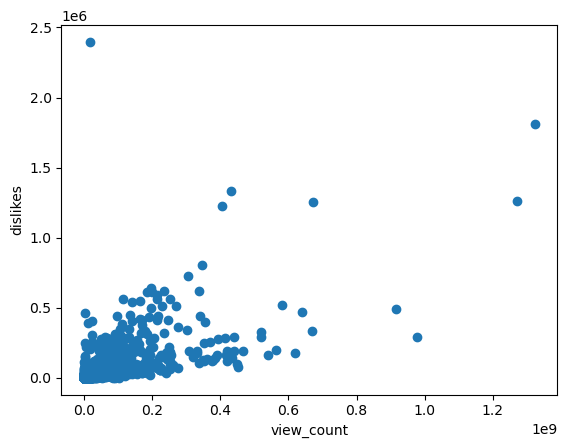

In [31]:
#plotting the scatter plot for view_count vs dislike to visualize the correlation

plt.scatter(youtube_dataframe["view_count"],youtube_dataframe["dislikes"])
plt.xlabel("view_count")
plt.ylabel("dislikes")
plt.show()

Yes, the number of views have effect on how many people disliked the video. there is positive correlation between views and dislikes. as the views get increases then the dislikes for video also get increases

### 14. Display all the information about the videos that were published in January, and mention the count of videos that were published in January

In [32]:
jan_video=youtube_dataframe[youtube_dataframe["published_at"].dt.month==1]
jan_video.head()

,video_id,title,channel_id,channel_title,published_at,view_count,likes,dislikes,comment_count,tags,description,comments,published_month
27,-2Gwm7QfBnE,Q&A With Naisha,UCYwNMbogQFzMccPSuy-pPWg,MianTwins,2021-01-21 00:05:47,872372,38626,239,621,,Hey Guys!!! this has been the most requested v...,I feel like Nate and Aishas personality match ...,Jan
48,-4sfXSHSxzA,SURPRISING BRENT WITH HIS TIKTOK CRUSH!!,UCPpATKqmMV-CNRNWYaDUwiA,Alexa Rivera,2021-01-16 21:40:04,6504784,262477,5779,7907,,He had no idea! Thank you guys so much for wat...,Thank you guys for watching and don't forget t...,Jan
95,-AJD1Fc5rpQ,WE ARE HAVING A BABY! | finding out i'm pregna...,UCVsTboAhpnuL6j-tDePvNwQ,Tess Christine,2021-01-03 21:53:48,533084,38965,119,1650,,I am so happy to tell you that I am pregnant!!...,Okay I needed a moment to collect my thoughts ...,Jan
103,-AuJiwjsmWk,Do Ugly Foods Taste Worse? Taste Test,UCzpCc5n9hqiVC7HhPwcIKEg,Good Mythical MORE,2021-01-19 11:00:01,1057077,22526,531,773,gmm good mythical morning rhettandlink rhett a...,"Today, we're doing a blind taste test to deter...","""there's nothing wrong with it being bent""\nI ...",Jan
182,-JhqO2KWr5U,Schlatt gets fit,UCWZp4y1jqBuvLtiyxSs_ZBw,Big guy,2021-01-24 22:50:57,1724965,119431,325,1578,jschlatt big guy jschlatt highlights schlatt j...,#jschlatt #schlatt #bigguy #short,Schlatt is single handedly wiping out all the ...,Jan


In [33]:
len(jan_video)

2099

There are 2099 videos are there in dataset which were published during Jan month

In [34]:
jan_video.describe()

,published_at,view_count,likes,dislikes,comment_count
count,2099,2.099000e+03,2.099000e+03,2099.000000,2.099000e+03
mean,2021-01-17 11:46:42.191043328,4.994213e+06,1.319975e+05,3625.592187,8.961238e+03
min,2021-01-01 00:00:54,2.845000e+04,2.800000e+01,3.000000,1.000000e+01
25%,2021-01-09 23:07:52.500000,4.369485e+05,1.045750e+04,250.000000,8.935000e+02
50%,2021-01-17 19:11:31,1.150769e+06,3.198100e+04,731.000000,2.356000e+03
75%,2021-01-25 14:00:01,3.257770e+06,1.082830e+05,2255.500000,6.321000e+03
max,2021-01-31 23:15:09,6.203274e+08,7.828036e+06,409144.000000,1.095119e+06
std,NaN,2.059545e+07,3.894440e+05,13975.280871,3.672056e+04


1. Average view count of videos during January month is 4994213, average likes during January month 131997, average dislikes during January month 3625, average comments during January is 8961.
2. The minimum views count for video during january month is 28450 and maximum is 620327400, the minimum likes during january for video is 28 and the maximum video likes are 7828036, the minimum dislikes during january for video is 3 and the maximum video dislikes are 409144, the minimum comments count during jan is 10 and the maximum comments are 1095119.
3. There are 20595450 variations in views, 389444 variation in likes, 13975 variation in dislikes, 36720 variation in comments during january month.
4. There 25% of views are below 436948, 25% of likes are below 1045, 25% of dislikes are below 250, 25% of comments are below 893 during January month. 
5. There 50% of views are below 1150769, 50% of likes are below 31981, 50% of dislikes are below 731, 50% of comments are below 2356 during January month.
6. There 75% of views are below 3257770, 75% of likes are below 108283, 75% of dislikes are below 2255, 75% of comments are below 6321 during January month.